In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Verify GPU availability for Kaggle session
device_name = tf.test.gpu_device_name()
if not device_name:
    print('Please activate GPU in Kaggle Settings > Accelerator')
else:
    print(f'Found GPU at: {device_name}')

2026-05-08 09:26:35.678518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778232395.924357      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778232395.987773      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778232396.494357      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778232396.494404      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778232396.494407      24 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0


I0000 00:00:1778232424.719663      24 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778232424.726222      24 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
#import os
#import tensorflow as tf
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- CONFIG ---
#DATA_DIR = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train"
#IMG_SIZE = (224, 224)
#BATCH_SIZE = 32

#print("Setup Complete. Ready to load data.")

In [3]:
# Paths for separate train and test folders
train_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train'
test_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test'

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20  
VAL_SPLIT = 0.2 # 20% for validation from train folder
model_name = "DenseNet121"

class_names = sorted(os.listdir(train_dir))
print(f"Classes: {class_names}")

Classes: ['benign', 'malignant']


In [4]:
#Cell 3: File Extraction (Train & Test)
def get_files_and_labels(path):
    file_paths = []
    labels = []
    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(path, class_name)
        for img_name in os.listdir(class_folder):
            file_paths.append(os.path.join(class_folder, img_name))
            labels.append(class_idx)
    return np.array(file_paths), np.array(labels)

# Load Train and Test file paths separately
train_file_paths, train_labels = get_files_and_labels(train_dir)
test_file_paths, test_labels = get_files_and_labels(test_dir)

print(f"Total Training Images: {len(train_file_paths)}")
print(f"Total Test Images: {len(test_file_paths)}")

Total Training Images: 322498
Total Test Images: 80212


In [5]:
#Cell 4: Training & Validation Split
# Split 20% from train for validation
X_train, X_val, y_train, y_val = train_test_split(
    train_file_paths, train_labels, test_size=VAL_SPLIT, random_state=42, stratify=train_labels
)

print(f"Final Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(test_file_paths)}")


Final Train: 257998 | Validation: 64500 | Test: 80212


In [6]:
#Cell 5: TensorFlow Data Pipeline
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.densenet.preprocess_input(img)
    return img, label

def create_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(X_train, y_train, shuffle=True)
val_ds = create_ds(X_val, y_val)
test_ds = create_ds(test_file_paths, test_labels) # Separate test folder data

I0000 00:00:1778232430.176077      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778232430.177449      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Large

# Load Pre-trained MobileNetV3
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Base layers are locked

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [8]:
EPOCHS = 20

# Best Model Checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "MobileNetV3_NoWeights_Best.h5", 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

Epoch 1/20


I0000 00:00:1778232441.424912      70 service.cc:152] XLA service 0x7838040425b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778232441.424947      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778232441.424951      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778232442.855851      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 09:27:30.849656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:27:30.987743: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:27:31.318196: E external/local_xl

8061/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9939 - loss: 0.0447 - precision: 0.0000e+00 - recall: 0.0000e+00

2026-05-08 09:37:27.472215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:37:27.606676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:37:27.916729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:37:28.053113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8063/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9939 - loss: 0.0447 - precision: 0.0000e+00 - recall: 0.0000e+00

2026-05-08 09:40:07.128561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:40:07.263536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:40:07.581635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 09:40:07.718278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8063/8063 ━━━━━━━━━━━━━━━━━━━━ 778s 94ms/step - accuracy: 0.9939 - loss: 0.0447 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9939 - val_loss: 0.0359 - val_precision: 0.6667 - val_recall: 0.0051
Epoch 2/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 409s 51ms/step - accuracy: 0.9939 - loss: 0.0356 - precision: 0.1572 - recall: 4.3717e-04 - val_accuracy: 0.9939 - val_loss: 0.0359 - val_precision: 0.6667 - val_recall: 0.0051
Epoch 3/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 396s 49ms/step - accuracy: 0.9939 - loss: 0.0355 - precision: 0.4484 - recall: 0.0020 - val_accuracy: 0.9939 - val_loss: 0.0355 - val_precision: 0.5000 - val_recall: 0.0025
Epoch 4/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 380s 47ms/step - accuracy: 0.9940 - loss: 0.0351 - precision: 0.5561 - recall: 0.0027 - val_accuracy: 0.9939 - val_loss: 0.0354 - val_precision: 0.5000 - val_recall: 0.0025
Epoch 5/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 385s 48ms/step - accuracy: 0.9940 - loss: 0.0349 - precision: 0.7805 - recall: 0.0041 - val_accur

Predicting on test data...
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 197s 76ms/step

     CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     80133
   malignant       0.00      0.00      0.00        79

    accuracy                           1.00     80212
   macro avg       0.50      0.50      0.50     80212
weighted avg       1.00      1.00      1.00     80212



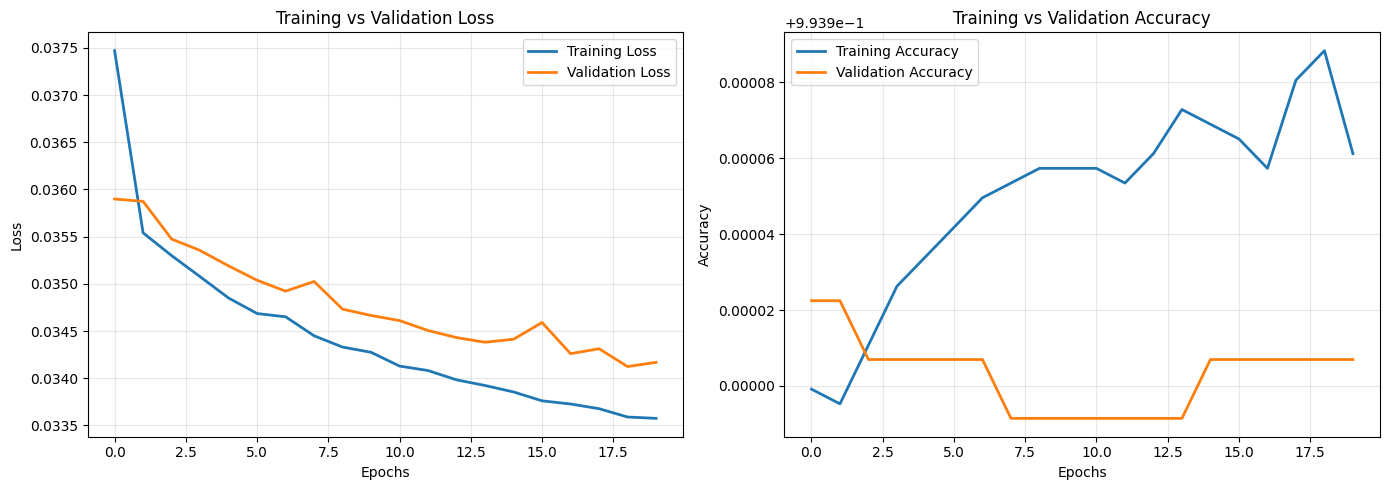

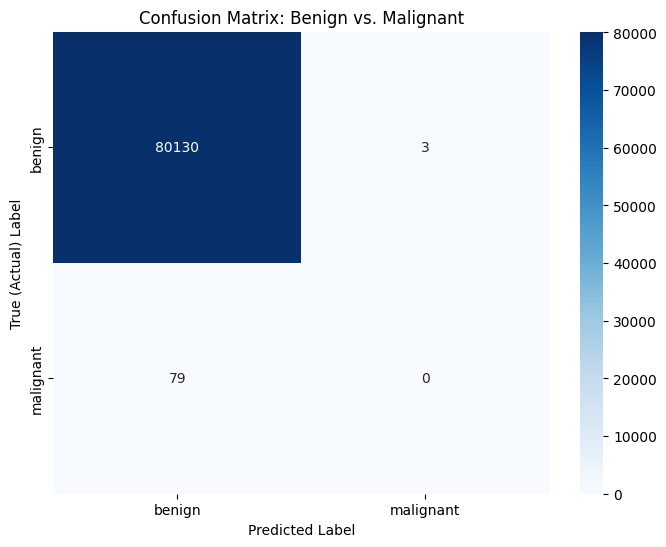

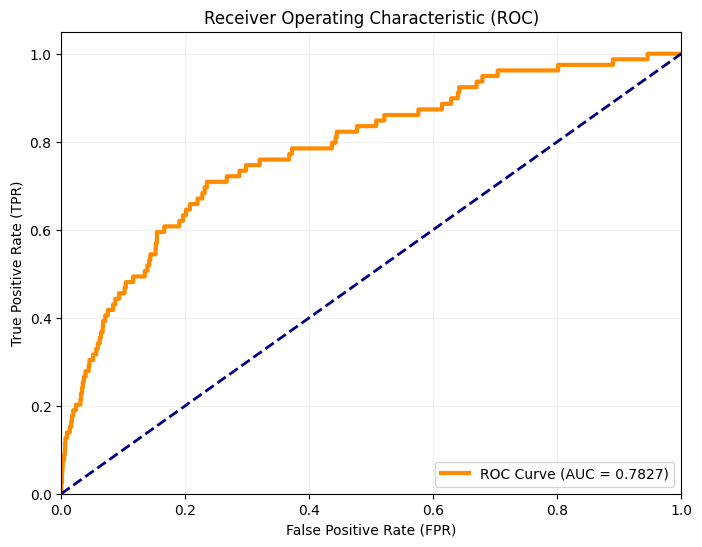


Final Analysis Summary:
Test Set ROC-AUC Score: 0.7827
Best Validation Accuracy Reached: 0.9939


In [9]:
#Cell 8: Performance Evaluation & Visualizations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. PREDICTIONS ---
# Generating probabilities for the test dataset
print("Predicting on test data...")
y_probs = model.predict(test_ds).flatten()
# Using 0.5 threshold to determine binary class (0: Benign, 1: Malignant)
y_pred_classes = (y_probs > 0.5).astype(int)
# Extracting true labels from the test dataset for comparison
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# --- 2. CLASSIFICATION REPORT ---
# This prints Precision, Recall, and F1-Score for both classes
print("\n" + "="*30)
print("     CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred_classes, target_names=class_names))
print("="*30)

# --- 3. TRAINING HISTORY (LOSS & ACCURACY) ---
history_dict = history.history
plt.figure(figsize=(14, 5))

# Subplot 1: Model Loss
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', lw=2)
plt.plot(history_dict['val_loss'], label='Validation Loss', lw=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Model Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Training Accuracy', lw=2)
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', lw=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. CONFUSION MATRIX ---
# Plotting the visual heatmap for easier error analysis
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Benign vs. Malignant')
plt.ylabel('True (Actual) Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 5. BINARY ROC CURVE ---
# Calculating False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

# --- 6. FINAL SUMMARY ---
print(f"\nFinal Analysis Summary:")
print(f"Test Set ROC-AUC Score: {roc_auc:.4f}")
print(f"Best Validation Accuracy Reached: {max(history_dict['val_accuracy']):.4f}")